In [1]:
# Fashion Product Images CNN

2026-06-28 10:37:34.387172: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782643054.582978      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782643054.645984      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782643055.100977      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782643055.101022      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782643055.101025      58 computation_placer.cc:177] computation placer alr

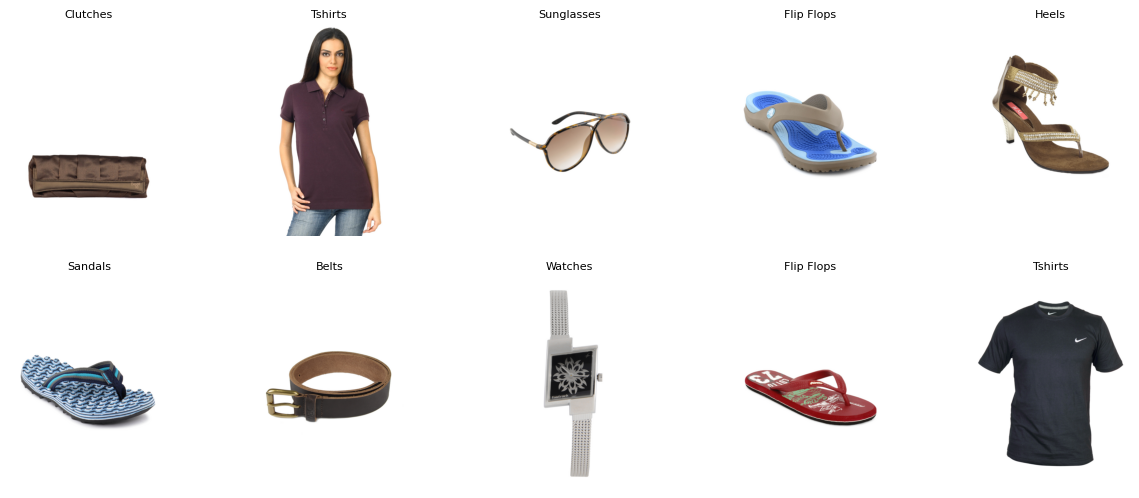

I0000 00:00:1782643276.400718      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/10


I0000 00:00:1782643280.731713     133 service.cc:152] XLA service 0x7d7d94004090 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782643280.731766     133 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782643281.114257     133 cuda_dnn.cc:529] Loaded cuDNN version 91002


 13/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0547 - loss: 4.8188  

I0000 00:00:1782643284.512017     133 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.2806 - loss: 3.2535 - val_accuracy: 0.4538 - val_loss: 2.2458
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5006 - loss: 2.0294 - val_accuracy: 0.6087 - val_loss: 1.5678
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5997 - loss: 1.6084 - val_accuracy: 0.6438 - val_loss: 1.3655
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6653 - loss: 1.2968 - val_accuracy: 0.6475 - val_loss: 1.3235
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7031 - loss: 1.1127 - val_accuracy: 0.6888 - val_loss: 1.1824
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7500 - loss: 0.9011 - val_accuracy: 0.7013 - val_loss: 1.1799
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7797 - loss: 0.7589 - val_accuracy: 0.7050 - val_loss: 1.2009
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8084 - loss: 0.6365 - val_accuracy: 0.722

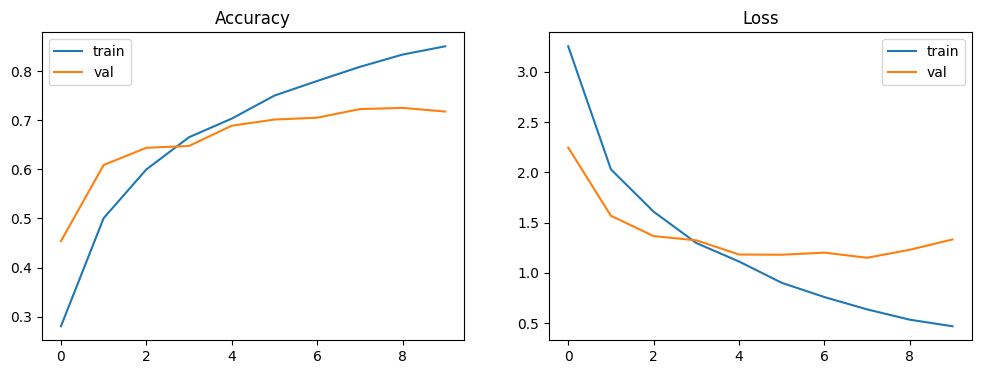

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array

BASE = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset"
df = pd.read_csv(f"{BASE}/styles.csv", on_bad_lines="skip")[["id", "articleType"]].dropna()
img_dir = f"{BASE}/images"

df["path"] = df["id"].astype(str).apply(lambda s: os.path.join(img_dir, s + ".jpg"))
df = df[df.path.apply(os.path.exists)]

df = df.sample(n=min(5000, len(df)), random_state=42).reset_index(drop=True)

fig, axs = plt.subplots(2, 5, figsize=(15, 6))
for ax, (_, r) in zip(axs.flat, df.sample(10, random_state=1).iterrows()):
    ax.imshow(Image.open(r.path))
    ax.set_title(r.articleType, fontsize=8)
    ax.axis("off")
plt.show()

classes = sorted(df.articleType.unique())
mp = {c: i for i, c in enumerate(classes)}
df["label"] = df.articleType.map(mp)

X = []
y = []
for _, r in df.iterrows():
    X.append(img_to_array(load_img(r.path, target_size=(128, 128))) / 255.0)
    y.append(r.label)

X = np.array(X, dtype="float32")
y = to_categorical(y, len(classes))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = tf.keras.Sequential([
    tf.keras.layers.Input((128, 128, 3)),
    tf.keras.layers.Conv2D(32, 3, activation="relu"), tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu"), tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation="relu"), tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(), 
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.5), 
    tf.keras.layers.Dense(len(classes), activation="softmax")
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
hist = model.fit(X_train, y_train, validation_split=0.2, epochs=10, batch_size=32)

print(model.evaluate(X_test, y_test))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(hist.history["accuracy"])
plt.plot(hist.history["val_accuracy"])
plt.legend(["train", "val"])
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.legend(["train", "val"])
plt.title("Loss")
plt.show()